<a href="https://colab.research.google.com/github/amina489/mathematical-modeling/blob/main/mathematical_modeling_and_ML_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
# Hybrid Mathematical Modeling and Deep Learning for Type 2 Diabetes Risk Prediction

## Project Objective

This project develops a machine-learning framework for estimating Type 2 diabetes risk.

The project combines:

- Clinical patient data
- Mathematical modeling
- Ordinary differential equations
- Numerical simulation
- Mathematical feature engineering
- Classical machine learning
- Deep learning
- Explainable AI

## Research Question

Can mathematical features generated from a simplified glucose-insulin
dynamical model improve diabetes-risk prediction compared with conventional
machine-learning features?

## Important Note

This is an educational and research-oriented computational project.
It is not a medical diagnostic system and should not be used for clinical decisions.

SyntaxError: invalid syntax (1967626643.py, line 5)

In [24]:

print("Welcome to the Diabetes Risk Prediction project.")

Welcome to the Diabetes Risk Prediction project.


In [25]:
!pip install -q numpy pandas matplotlib seaborn scikit-learn scipy xgboost tensorflow shap ucimlrepo

In [26]:
import numpy as np

print("NumPy imported successfully.")
print("NumPy version:", np.__version__)

NumPy imported successfully.
NumPy version: 2.1.3


In [27]:
import pandas as pd

print("Pandas imported successfully.")
print("Pandas version:", pd.__version__)

Pandas imported successfully.
Pandas version: 2.2.3


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Matplotlib imported successfully.")
print("Seaborn imported successfully.")

Matplotlib imported successfully.
Seaborn imported successfully.


In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier

print("Scikit-learn models imported successfully.")
print("XGBoost imported successfully.")

Scikit-learn models imported successfully.
XGBoost imported successfully.


In [30]:
from scipy.integrate import solve_ivp

print("SciPy imported successfully.")
print("Numerical differential-equation solver is ready.")

SciPy imported successfully.
Numerical differential-equation solver is ready.


In [31]:
import tensorflow as tf

print("TensorFlow imported successfully.")
print("TensorFlow version:", tf.__version__)

TensorFlow imported successfully.
TensorFlow version: 2.20.0


In [32]:
import shap

print("SHAP imported successfully.")
print("Explainable AI tools are ready.")

SHAP imported successfully.
Explainable AI tools are ready.


In [33]:
from ucimlrepo import fetch_ucirepo

print("UCI dataset interface imported successfully.")

UCI dataset interface imported successfully.


In [34]:
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("Random seed:", RANDOM_STATE)
print("Reproducibility settings established.")

Random seed: 42
Reproducibility settings established.


In [35]:
# Import pandas.
import pandas as pd

# Store the direct download address of the UCI dataset.
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00529/diabetes_data_upload.csv"

# Download the CSV file directly into a Pandas dataframe.
df_original = pd.read_csv(url)

# Display the size of the downloaded dataset.
print("Dataset downloaded successfully.")
print()
print("Number of rows:", df_original.shape[0])
print("Number of columns:", df_original.shape[1])

# Display the column names.
print()
print("Column names:")
print(df_original.columns.tolist())

# Display the first five rows.
print()
print("First five rows:")
display(df_original.head())

Dataset downloaded successfully.

Number of rows: 520
Number of columns: 17

Column names:
['Age', 'Gender', 'Polyuria', 'Polydipsia', 'sudden weight loss', 'weakness', 'Polyphagia', 'Genital thrush', 'visual blurring', 'Itching', 'Irritability', 'delayed healing', 'partial paresis', 'muscle stiffness', 'Alopecia', 'Obesity', 'class']

First five rows:


,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,Male,No,Yes,No,Yes,No,No,No,Yes,No,Yes,No,Yes,Yes,Yes,Positive
1,58,Male,No,No,No,Yes,No,No,Yes,No,No,No,Yes,No,Yes,No,Positive
2,41,Male,Yes,No,No,Yes,Yes,No,No,Yes,No,Yes,No,Yes,Yes,No,Positive
3,45,Male,No,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No,No,No,No,Positive
4,60,Male,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Positive


In [36]:
# Create X by removing the target column.
# X contains the information about each patient.
X_raw = df_original.drop(columns=["class"])

# Create y using only the target column.
# y tells us whether the patient belongs to the Positive
# or Negative diabetes class.
y_raw = df_original[["class"]]

# Create a simple target variable containing only the class values.
target = y_raw["class"]

# Confirm that all three variables were created.
print("X_raw created:", X_raw is not None)
print("y_raw created:", y_raw is not None)
print("target created:", target is not None)

print()

# Display their dimensions.
print("X_raw shape:", X_raw.shape)
print("y_raw shape:", y_raw.shape)
print("Number of target values:", len(target))

X_raw created: True
y_raw created: True
target created: True

X_raw shape: (520, 16)
y_raw shape: (520, 1)
Number of target values: 520


In [37]:
# Display the target column name.
print("Target column:")
print(y_raw.columns.tolist())

print()

# Count the number of patients in each class.
class_counts = target.value_counts()

print("Number of patients in each class:")
print(class_counts)

print()

# Calculate the percentage of patients in each class.
class_percentages = target.value_counts(normalize=True) * 100

print("Percentage of patients in each class:")
print(class_percentages.round(2))

Target column:
['class']

Number of patients in each class:
class
Positive    320
Negative    200
Name: count, dtype: int64

Percentage of patients in each class:
class
Positive    61.54
Negative    38.46
Name: proportion, dtype: float64


In [38]:
# Make a copy of the original dataset.
df = df_original.copy()

# Rename the target column from "class" to "diabetes".
df = df.rename(columns={"class": "diabetes"})

# Display the dataset dimensions.
print("Complete dataset created.")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print()

# Display the first five rows.
print("First five rows:")
display(df.head())

Complete dataset created.
Rows: 520
Columns: 17

First five rows:


,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,diabetes
0,40,Male,No,Yes,No,Yes,No,No,No,Yes,No,Yes,No,Yes,Yes,Yes,Positive
1,58,Male,No,No,No,Yes,No,No,Yes,No,No,No,Yes,No,Yes,No,Positive
2,41,Male,Yes,No,No,Yes,Yes,No,No,Yes,No,Yes,No,Yes,Yes,No,Positive
3,45,Male,No,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No,No,No,No,Positive
4,60,Male,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Positive


In [39]:
# Create a copy of the dataframe.
df_clean = df.copy()

# Remove spaces at the beginning and end of column names.
df_clean.columns = df_clean.columns.str.strip()

# Convert all column names to lowercase.
df_clean.columns = df_clean.columns.str.lower()

# Replace spaces with underscores.
df_clean.columns = df_clean.columns.str.replace(" ", "_")

# Display the cleaned column names.
print("Cleaned column names:")
print(df_clean.columns.tolist())

Cleaned column names:
['age', 'gender', 'polyuria', 'polydipsia', 'sudden_weight_loss', 'weakness', 'polyphagia', 'genital_thrush', 'visual_blurring', 'itching', 'irritability', 'delayed_healing', 'partial_paresis', 'muscle_stiffness', 'alopecia', 'obesity', 'diabetes']


In [40]:
# Display the data type of every column.
print("Data types of all columns:")
print(df_clean.dtypes)

Data types of all columns:
age                    int64
gender                object
polyuria              object
polydipsia            object
sudden_weight_loss    object
weakness              object
polyphagia            object
genital_thrush        object
visual_blurring       object
itching               object
irritability          object
delayed_healing       object
partial_paresis       object
muscle_stiffness      object
alopecia              object
obesity               object
diabetes              object
dtype: object


In [41]:
# Check whether the dataset variable df_clean exists.
if "df_clean" not in globals():

    # If df_clean does not exist, create it from df_original.
    if "df_original" in globals():

        df_clean = df_original.copy()

        # Clean the column names in the same way as Cell 17.
        df_clean.columns = df_clean.columns.str.strip()
        df_clean.columns = df_clean.columns.str.lower()
        df_clean.columns = df_clean.columns.str.replace(" ", "_")

        print("df_clean was recreated successfully.")

    else:
        # If neither dataframe exists, download the dataset again.
        import pandas as pd

        url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00529/diabetes_data_upload.csv"

        df_original = pd.read_csv(url)

        # Create df_clean.
        df_clean = df_original.copy()

        # Clean the column names.
        df_clean.columns = df_clean.columns.str.strip()
        df_clean.columns = df_clean.columns.str.lower()
        df_clean.columns = df_clean.columns.str.replace(" ", "_")

        print("Dataset was downloaded and df_clean was created successfully.")

else:
    print("df_clean is already available.")

# Count missing values in every column.
missing_values = df_clean.isnull().sum()

print()
print("Missing values in each column:")

# Display the missing-value results.
display(missing_values)

df_clean is already available.

Missing values in each column:


,0
age,0
gender,0
polyuria,0
polydipsia,0
sudden_weight_loss,0
weakness,0
polyphagia,0
genital_thrush,0
visual_blurring,0
itching,0


In [42]:
# Make sure the required dataframe exists.
if "df_clean" not in globals():
    raise RuntimeError(
        "df_clean is missing. Please run Cell 19 again before Cell 20."
    )

# Count completely duplicated rows.
duplicate_count = df_clean.duplicated().sum()

# Display the result.
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 269


In [43]:
# Make sure df_clean exists.
if "df_clean" not in globals():
    raise RuntimeError(
        "df_clean is missing. Please run Cell 19 again."
    )

# Find columns containing text/categorical data.
categorical_columns = df_clean.select_dtypes(
    include=["object"]
).columns.tolist()

# Display the categorical columns.
print("Categorical columns:")
print(categorical_columns)

print()

# Display the unique values in each categorical column.
print("Unique values in each categorical column:")

for column in categorical_columns:
    print()
    print(column, ":", df_clean[column].unique())

Categorical columns:
['gender', 'polyuria', 'polydipsia', 'sudden_weight_loss', 'weakness', 'polyphagia', 'genital_thrush', 'visual_blurring', 'itching', 'irritability', 'delayed_healing', 'partial_paresis', 'muscle_stiffness', 'alopecia', 'obesity', 'diabetes']

Unique values in each categorical column:

gender : ['Male' 'Female']

polyuria : ['No' 'Yes']

polydipsia : ['Yes' 'No']

sudden_weight_loss : ['No' 'Yes']

weakness : ['Yes' 'No']

polyphagia : ['No' 'Yes']

genital_thrush : ['No' 'Yes']

visual_blurring : ['No' 'Yes']

itching : ['Yes' 'No']

irritability : ['No' 'Yes']

delayed_healing : ['Yes' 'No']

partial_paresis : ['No' 'Yes']

muscle_stiffness : ['Yes' 'No']

alopecia : ['Yes' 'No']

obesity : ['Yes' 'No']

diabetes : ['Positive' 'Negative']


In [44]:
# Make sure df_clean exists.
if "df_clean" not in globals():
    raise RuntimeError(
        "df_clean is missing. Please run Cell 19 again."
    )

# Create a separate copy for machine learning.
df_model = df_clean.copy()

# Display the dimensions.
print("Machine-learning dataframe created successfully.")
print("Rows:", df_model.shape[0])
print("Columns:", df_model.shape[1])

Machine-learning dataframe created successfully.
Rows: 520
Columns: 17


In [45]:
# Make sure df_model exists.
if "df_model" not in globals():
    df_model = df_clean.copy()

# Define the mapping for feature values.
feature_mapping = {
    "Yes": 1,
    "No": 0,
    "Male": 1,
    "Female": 0
}

# Convert categorical feature values.
for column in df_model.columns:

    # The target is handled separately in Cell 24.
    if column != "diabetes":
        df_model[column] = df_model[column].replace(feature_mapping)

# Display the first five rows.
print("Feature encoding completed.")
display(df_model.head())

Feature encoding completed.


/tmp/ipykernel_549/70054917.py:18: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_model[column] = df_model[column].replace(feature_mapping)


,age,gender,polyuria,polydipsia,sudden_weight_loss,weakness,polyphagia,genital_thrush,visual_blurring,itching,irritability,delayed_healing,partial_paresis,muscle_stiffness,alopecia,obesity,diabetes
0,40,1,0,1,0,1,0,0,0,1,0,1,0,1,1,1,Positive
1,58,1,0,0,0,1,0,0,1,0,0,0,1,0,1,0,Positive
2,41,1,1,0,0,1,1,0,0,1,0,1,0,1,1,0,Positive
3,45,1,0,0,1,1,1,1,0,1,0,1,0,0,0,0,Positive
4,60,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,Positive


In [46]:
# Make sure df_model exists.
if "df_model" not in globals():
    df_model = df_clean.copy()

# Define the target mapping.
target_mapping = {
    "Positive": 1,
    "Negative": 0
}

# Convert the diabetes target into numbers.
df_model["diabetes"] = df_model["diabetes"].map(target_mapping)

# Display the unique target values.
print("Unique target values:")
print(df_model["diabetes"].unique())

print()

# Display the first five rows.
display(df_model.head())

Unique target values:
[1 0]



,age,gender,polyuria,polydipsia,sudden_weight_loss,weakness,polyphagia,genital_thrush,visual_blurring,itching,irritability,delayed_healing,partial_paresis,muscle_stiffness,alopecia,obesity,diabetes
0,40,1,0,1,0,1,0,0,0,1,0,1,0,1,1,1,1
1,58,1,0,0,0,1,0,0,1,0,0,0,1,0,1,0,1
2,41,1,1,0,0,1,1,0,0,1,0,1,0,1,1,0,1
3,45,1,0,0,1,1,1,1,0,1,0,1,0,0,0,0,1
4,60,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1


In [47]:
# Check the number of missing values in every column.
conversion_missing = df_model.isnull().sum()

# Keep only columns containing missing values.
columns_with_missing = conversion_missing[
    conversion_missing > 0
]

# Display the result.
if len(columns_with_missing) == 0:

    print("No missing values were created during encoding.")
else:
    print("Warning: missing values were found.")
    print(columns_with_missing)

No missing values were created during encoding.


In [48]:
# Make sure df_model exists.
if "df_model" not in globals():
    raise RuntimeError(
        "df_model is missing. Please run Cells 22-25 first."
    )

# Create the feature matrix.
X = df_model.drop(columns=["diabetes"])

# Create the target vector.
y = df_model["diabetes"]

# Display their dimensions.
print("Features X shape:", X.shape)
print("Target y shape:", y.shape)

print()

# Display the feature names.
print("Feature columns:")
print(X.columns.tolist())

Features X shape: (520, 16)
Target y shape: (520,)

Feature columns:
['age', 'gender', 'polyuria', 'polydipsia', 'sudden_weight_loss', 'weakness', 'polyphagia', 'genital_thrush', 'visual_blurring', 'itching', 'irritability', 'delayed_healing', 'partial_paresis', 'muscle_stiffness', 'alopecia', 'obesity']


In [49]:
# Check whether X contains missing values.
x_missing = X.isnull().sum().sum()

# Check whether y contains missing values.
y_missing = y.isnull().sum()

# Display the results.
print("Missing values in X:", x_missing)
print("Missing values in y:", y_missing)

print()

# Display the target classes.
print("Target classes:")
print(sorted(y.unique()))

Missing values in X: 0
Missing values in y: 0

Target classes:
[np.int64(0), np.int64(1)]


In [50]:
# Import the train-test split function.
from sklearn.model_selection import train_test_split

# Define the random seed if it does not already exist.
if "RANDOM_STATE" not in globals():
    RANDOM_STATE = 42

# Split the dataset.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

# Display the resulting shapes.
print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print()

print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training feature shape: (416, 16)
Testing feature shape: (104, 16)

Training target shape: (416,)
Testing target shape: (104,)


In [51]:
# Calculate the percentage of positive cases in the training set.
train_positive_percentage = y_train.mean() * 100

# Calculate the percentage of positive cases in the testing set.
test_positive_percentage = y_test.mean() * 100

# Display the results.
print(
    "Positive cases in training data:",
    round(train_positive_percentage, 2),
    "%"
)

print(
    "Positive cases in testing data:",
    round(test_positive_percentage, 2),
    "%"
)

Positive cases in training data: 61.54 %
Positive cases in testing data: 61.54 %


In [52]:
# Import StandardScaler.
from sklearn.preprocessing import StandardScaler

# Create the scaler.
scaler = StandardScaler()

# Learn the scaling parameters from the training data
# and transform the training data.
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same scaling parameters to the test data.
X_test_scaled = scaler.transform(X_test)

# Display the resulting shapes.
print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Scaled training data shape: (416, 16)
Scaled testing data shape: (104, 16)


In [53]:
# Calculate the mean of every scaled training feature.
scaled_means = X_train_scaled.mean(axis=0)

# Calculate the standard deviation of every scaled training feature.
scaled_stds = X_train_scaled.std(axis=0)

# Display the first five means.
print("First five scaled feature means:")
print(np.round(scaled_means[:5], 3))

print()

# Display the first five standard deviations.
print("First five scaled feature standard deviations:")
print(np.round(scaled_stds[:5], 3))

First five scaled feature means:
[ 0.  0. -0.  0.  0.]

First five scaled feature standard deviations:
[1. 1. 1. 1. 1.]


In [54]:
# Import Logistic Regression.
from sklearn.linear_model import LogisticRegression

# Create the logistic regression model.
logistic_model = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000
)

# Train the model using the scaled training data.
logistic_model.fit(X_train_scaled, y_train)

# Confirm that training completed.
print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [55]:
# Predict the class for every patient in the test set.
y_pred_logistic = logistic_model.predict(X_test_scaled)

# Predict the probability of the positive class.
y_prob_logistic = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

# Display the first ten predicted classes.
print("First 10 predicted classes:")
print(y_pred_logistic[:10])

print()

# Display the first ten predicted probabilities.
print("First 10 predicted probabilities:")
print(np.round(y_prob_logistic[:10], 3))

First 10 predicted classes:
[0 1 1 0 0 1 1 0 1 0]

First 10 predicted probabilities:
[0.281 0.979 0.997 0.313 0.049 0.919 1.    0.042 1.    0.029]


In [56]:
# Import the evaluation metrics.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Calculate accuracy.
accuracy_logistic = accuracy_score(
    y_test,
    y_pred_logistic
)

# Calculate precision.
precision_logistic = precision_score(
    y_test,
    y_pred_logistic
)

# Calculate recall.
recall_logistic = recall_score(
    y_test,
    y_pred_logistic
)

# Calculate F1 score.
f1_logistic = f1_score(
    y_test,
    y_pred_logistic
)

# Calculate ROC-AUC.
auc_logistic = roc_auc_score(
    y_test,
    y_prob_logistic
)

# Display all metrics.
print("Logistic Regression Results")
print("----------------------------")
print("Accuracy :", round(accuracy_logistic, 4))
print("Precision:", round(precision_logistic, 4))
print("Recall   :", round(recall_logistic, 4))
print("F1 Score :", round(f1_logistic, 4))
print("ROC-AUC  :", round(auc_logistic, 4))

Logistic Regression Results
----------------------------
Accuracy : 0.9423
Precision: 0.9833
Recall   : 0.9219
F1 Score : 0.9516
ROC-AUC  : 0.9902


In [57]:
# Import the confusion matrix function.
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix.
cm_logistic = confusion_matrix(
    y_test,
    y_pred_logistic
)

# Display the confusion matrix.
print("Logistic Regression Confusion Matrix:")
print(cm_logistic)

Logistic Regression Confusion Matrix:
[[39  1]
 [ 5 59]]


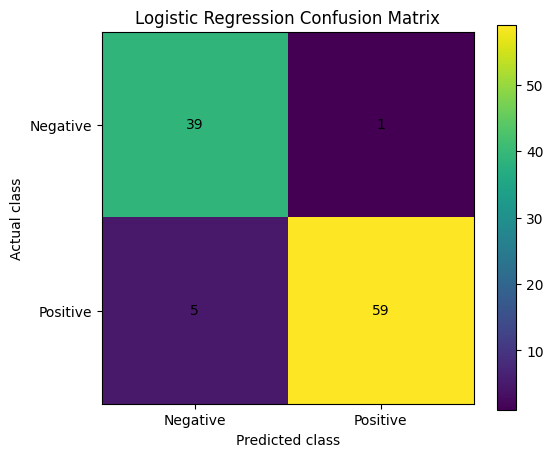

In [58]:
# Import Matplotlib.
import matplotlib.pyplot as plt

# Create the figure.
plt.figure(figsize=(6, 5))

# Display the confusion matrix.
plt.imshow(cm_logistic)

# Add a color scale.
plt.colorbar()

# Add the axis labels.
plt.xlabel("Predicted class")
plt.ylabel("Actual class")

# Add the title.
plt.title("Logistic Regression Confusion Matrix")

# Add the class names to the axes.
plt.xticks([0, 1], ["Negative", "Positive"])
plt.yticks([0, 1], ["Negative", "Positive"])

# Write the numerical values inside each cell.
for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm_logistic[i, j],
            ha="center",
            va="center"
        )

# Display the plot.
plt.show()

In [59]:
# Import Random Forest.
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest model.
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    class_weight="balanced"
)

# Train the model.
random_forest_model.fit(X_train, y_train)

# Confirm training.
print("Random Forest trained successfully.")

Random Forest trained successfully.


In [60]:
# Predict classes.
y_pred_rf = random_forest_model.predict(X_test)

# Predict positive-class probabilities.
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics.
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

# Display the results.
print("Random Forest Results")
print("---------------------")
print("Accuracy :", round(accuracy_rf, 4))
print("Precision:", round(precision_rf, 4))
print("Recall   :", round(recall_rf, 4))
print("F1 Score :", round(f1_rf, 4))
print("ROC-AUC  :", round(auc_rf, 4))

Random Forest Results
---------------------
Accuracy : 0.9904
Precision: 1.0
Recall   : 0.9844
F1 Score : 0.9921
ROC-AUC  : 1.0


In [61]:
# Create a dictionary containing the baseline results.
baseline_results = {
    "Logistic Regression": {
        "Accuracy": accuracy_logistic,
        "Precision": precision_logistic,
        "Recall": recall_logistic,
        "F1": f1_logistic,
        "ROC-AUC": auc_logistic
    },
    "Random Forest": {
        "Accuracy": accuracy_rf,
        "Precision": precision_rf,
        "Recall": recall_rf,
        "F1": f1_rf,
        "ROC-AUC": auc_rf
    }
}

# Convert the results into a dataframe.
baseline_results_df = pd.DataFrame(baseline_results).T

# Round the values for easier reading.
baseline_results_df = baseline_results_df.round(4)

# Display the comparison.
print("Baseline Model Comparison:")
display(baseline_results_df)

Baseline Model Comparison:


,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.9423,0.9833,0.9219,0.9516,0.9902
Random Forest,0.9904,1.0000,0.9844,0.9921,1.0000
